In [1]:
import pandas as pd
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.data import AUTOTUNE
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import Dense,Conv2D,Input,Flatten,MaxPool2D,Dropout
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.layers import MaxPooling2D

2021-10-07 03:20:08.705513: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0


# Read CSV

In [2]:
df = pd.read_csv('../input/digit-recognizer/train.csv')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Create Dataset

In [4]:
X = []
Y = []
for i in df.values:
    X.append(i[1:].reshape((28,28,1)))
    Y.append(i[0])

In [5]:
X = np.array(X)
Y = np.array(Y)

In [6]:
X_train,X_next, Y_train, Y_next = train_test_split(X,Y,random_state=46,test_size = 0.4,stratify=Y)
X_val, X_test, Y_val, Y_test = train_test_split(X_next,Y_next,random_state=46,test_size = 0.3,stratify=Y_next)

In [7]:
Y_train = to_categorical(Y_train)
Y_val = to_categorical(Y_val)
Y_test = to_categorical(Y_test)

In [8]:
def create_dataset(dataset):
    ds=tf.data.Dataset.from_tensor_slices(dataset)
    ds=ds.batch(32).prefetch(buffer_size=AUTOTUNE)
    return ds

trainds = create_dataset((X_train,Y_train))
testds = create_dataset((X_test,Y_test))
valds = create_dataset((X_val,Y_val))

2021-10-07 03:20:15.945164: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2021-10-07 03:20:15.948363: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2021-10-07 03:20:15.993152: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-10-07 03:20:15.993887: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:00:04.0 name: Tesla P100-PCIE-16GB computeCapability: 6.0
coreClock: 1.3285GHz coreCount: 56 deviceMemorySize: 15.90GiB deviceMemoryBandwidth: 681.88GiB/s
2021-10-07 03:20:15.993970: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
2021-10-07 03:20:16.026749: I tensorflow/stream_executor/platform/def

# Create Model CNN

In [71]:
model = Sequential()
model.add(Conv2D(128, (3,3), padding='same', input_shape=(28,28,1), activation='relu'))
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(2))

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(2))

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

In [72]:
model.summary()

Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_53 (Conv2D)           (None, 28, 28, 128)       1280      
_________________________________________________________________
conv2d_54 (Conv2D)           (None, 28, 28, 128)       147584    
_________________________________________________________________
conv2d_55 (Conv2D)           (None, 28, 28, 128)       147584    
_________________________________________________________________
max_pooling2d_25 (MaxPooling (None, 14, 14, 128)       0         
_________________________________________________________________
conv2d_56 (Conv2D)           (None, 14, 14, 128)       147584    
_________________________________________________________________
conv2d_57 (Conv2D)           (None, 14, 14, 128)       147584    
_________________________________________________________________
conv2d_58 (Conv2D)           (None, 14, 14, 128)      

# Train Model

In [73]:
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [74]:
model.fit(trainds,epochs=10,validation_data=valds)

Epoch 1/10
788/788 [==============================] - 10s 11ms/step - loss: 0.8712 - accuracy: 0.7106 - val_loss: 0.1098 - val_accuracy: 0.9650
Epoch 2/10
788/788 [==============================] - 9s 11ms/step - loss: 0.1431 - accuracy: 0.9565 - val_loss: 0.0702 - val_accuracy: 0.9782
Epoch 3/10
788/788 [==============================] - 9s 11ms/step - loss: 0.0922 - accuracy: 0.9739 - val_loss: 0.0618 - val_accuracy: 0.9814
Epoch 4/10
788/788 [==============================] - 9s 11ms/step - loss: 0.0637 - accuracy: 0.9812 - val_loss: 0.0640 - val_accuracy: 0.9814
Epoch 5/10
788/788 [==============================] - 9s 11ms/step - loss: 0.0561 - accuracy: 0.9825 - val_loss: 0.0576 - val_accuracy: 0.9849
Epoch 6/10
788/788 [==============================] - 9s 12ms/step - loss: 0.0443 - accuracy: 0.9857 - val_loss: 0.0509 - val_accuracy: 0.9856
Epoch 7/10
788/788 [==============================] - 9s 11ms/step - loss: 0.0409 - accuracy: 0.9883 - val_loss: 0.0381 - val_accuracy: 0.987

In [75]:
model.evaluate(testds)

158/158 [==============================] - 1s 4ms/step - loss: 0.0466 - accuracy: 0.9895


[0.046586520969867706, 0.9894841313362122]

# Test Model To test.csv

In [76]:
df1 = pd.read_csv('../input/digit-recognizer/test.csv')

In [77]:
testX = []
for i in df1.values:
    testX.append(i[:].reshape((28,28,1)))

In [78]:
testX = np.array(testX)

In [79]:
pred = model.predict(testX)

In [80]:
result_pred = [np.argmax(x) for x in pred]

In [81]:
my_submission = pd.DataFrame({'ImageId': df1.index + 1, 'Label': result_pred})
my_submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


In [87]:
my_submission.to_csv('submission.csv', index=False)

In [84]:
import matplotlib.pyplot as plt

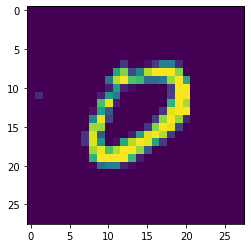

In [86]:
plt.imshow(testX[3])